In [1]:
import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_bounds
from rasterio.warp import transform_bounds
import geopandas as gpd
import numpy as np
import pandas as pd
import os
import zipfile

In [2]:
# === SHAPEFILE LADEN UND VORBEREITEN ===

# Shapefile extrahieren und laden
shapefile_zip = r"\\141.20.141.12\SAN_BioGeo\_HiWi\Ruben\thesis\data\Ecoregions2017.zip"
extract_dir = r"\\141.20.141.12\SAN_BioGeo\_HiWi\Ruben\thesis\data\temp_ecoregions"



# Extrahieren falls noch nicht geschehen
if not os.path.exists(extract_dir):
    os.makedirs(extract_dir)
    with zipfile.ZipFile(shapefile_zip, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

# Shapefile finden und laden
shapefile_path = None
for file in os.listdir(extract_dir):
    if file.endswith('.shp'):
        shapefile_path = os.path.join(extract_dir, file)
        break

if shapefile_path:
    print(f"Lade Shapefile: {shapefile_path}")
    ecoregions_gdf = gpd.read_file(shapefile_path)
    print(f"Anzahl Features: {len(ecoregions_gdf)}")
    print(f"Spalten: {list(ecoregions_gdf.columns)}")
    print(f"CRS: {ecoregions_gdf.crs}")
else:
    raise FileNotFoundError("Kein Shapefile in der ZIP-Datei gefunden")



Lade Shapefile: \\141.20.141.12\SAN_BioGeo\_HiWi\Ruben\thesis\data\temp_ecoregions\Ecoregions2017.shp
Anzahl Features: 847
Spalten: ['OBJECTID', 'ECO_NAME', 'BIOME_NUM', 'BIOME_NAME', 'REALM', 'ECO_BIOME_', 'NNH', 'ECO_ID', 'SHAPE_LENG', 'SHAPE_AREA', 'NNH_NAME', 'COLOR', 'COLOR_BIO', 'COLOR_NNH', 'LICENSE', 'geometry']
CRS: EPSG:4326


In [3]:
# === WOODY_BURNED_COMBINED EIGENSCHAFTEN LADEN ===

raster_path = r"\\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs\02_Trajectories_Full\woody_burned_combined.tif"

print("Lade Raster-Eigenschaften ...")
with rasterio.open(raster_path) as src:
    bounds = src.bounds  # EPSG:3035 Koordinaten
    crs = src.crs       # EPSG:3035
    transform = src.transform
    width = src.width   # 10483
    height = src.height # 9660

print(f"Raster bounds (EPSG:3035): {bounds}")
print(f"Raster Dimensionen: {width} x {height}")
print(f"Auflösung: {transform[0]}m")

Lade Raster-Eigenschaften ...
Raster bounds (EPSG:3035): BoundingBox(left=2477500.0, bottom=1289000.0, right=7719000.0, top=6119000.0)
Raster Dimensionen: 10483 x 9660
Auflösung: 500.0m


In [4]:
# === ECOREGIONS AUF STUDIENGEBIET BESCHRÄNKEN ===

# Ecoregions zu EPSG:3035 transformieren (falls noch nicht)
if ecoregions_gdf.crs != crs:
    print(f"Transformiere von {ecoregions_gdf.crs} zu {crs}")
    ecoregions_gdf = ecoregions_gdf.to_crs(crs)

# Studiengebiet-Bounding Box als Geometrie
from shapely.geometry import box
study_bbox = box(*bounds)

# Ecoregions auf Studiengebiet clippen
print("Clippe Ecoregions auf Studiengebiet...")
ecoregions_clipped = gpd.clip(ecoregions_gdf, study_bbox)
print(f"Anzahl Ecoregions im Studiengebiet: {len(ecoregions_clipped)}")

# Verfügbare Attribute anzeigen
print(f"Verfügbare Attribute: {list(ecoregions_clipped.columns)}")


Transformiere von EPSG:4326 zu EPSG:3035
Clippe Ecoregions auf Studiengebiet...
Anzahl Ecoregions im Studiengebiet: 88
Verfügbare Attribute: ['OBJECTID', 'ECO_NAME', 'BIOME_NUM', 'BIOME_NAME', 'REALM', 'ECO_BIOME_', 'NNH', 'ECO_ID', 'SHAPE_LENG', 'SHAPE_AREA', 'NNH_NAME', 'COLOR', 'COLOR_BIO', 'COLOR_NNH', 'LICENSE', 'geometry']


In [6]:
# === GEWÜNSCHTE ATTRIBUTE AUSWÄHLEN ===

# Alle verfügbaren numerischen Attribute (passen Sie nach Bedarf an)
numeric_properties = ['ECO_ID', 'BIOME_NUM', 'OBJECTID']  # Anpassen basierend auf verfügbaren Spalten
string_properties = ['ECO_NAME', 'BIOME_NAME', 'COLOR', 'COLOR_BIO']  # Für CSV-Export

# Überprüfen welche Spalten tatsächlich vorhanden sind
available_numeric = [col for col in numeric_properties if col in ecoregions_clipped.columns]
available_string = [col for col in string_properties if col in ecoregions_clipped.columns]

print(f"Verfügbare numerische Attribute: {available_numeric}")
print(f"Verfügbare String-Attribute: {available_string}")


Verfügbare numerische Attribute: ['ECO_ID', 'BIOME_NUM', 'OBJECTID']
Verfügbare String-Attribute: ['ECO_NAME', 'BIOME_NAME', 'COLOR', 'COLOR_BIO']


In [8]:
# === RASTERISIERUNG ===

print("Erstelle Multi-Band-Raster...")

# Leeres Array für alle Bänder erstellen
raster_bands = []

for i, prop in enumerate(available_numeric):
    print(f"Rasterisiere {prop}...")
    
    # Rasterisierung des aktuellen Attributs
    raster_band = rasterize(
        [(geom, value) for geom, value in zip(ecoregions_clipped.geometry, ecoregions_clipped[prop])],
        out_shape=(height, width),
        transform=transform,
        fill=0,  # NoData-Wert
        dtype='uint16'
    )
    
    raster_bands.append(raster_band)


# Alle Bänder zu einem Array kombinieren
ecoregions_raster = np.array(raster_bands)

print(f"Raster erstellt: {ecoregions_raster.shape}")

Erstelle Multi-Band-Raster...
Rasterisiere ECO_ID...
Rasterisiere BIOME_NUM...
Rasterisiere OBJECTID...
Raster erstellt: (3, 9660, 10483)


In [9]:
# === RASTER SPEICHERN ===

output_path = r"\\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs\03_Ecoregions\ecoregions_500m_3035.tif"
if not os.path.exists(os.path.dirname(output_path)):
    os.makedirs(os.path.dirname(output_path))
print(f"Speichere Raster: {output_path}")

with rasterio.open(
    output_path,
    'w',
    driver='GTiff',
    height=height,
    width=width,
    count=len(available_numeric),
    dtype='uint16',
    crs=crs,
    transform=transform,
    compress='lzw'
) as dst:
    for i, band in enumerate(raster_bands):
        dst.write(band, i + 1)
        dst.set_band_description(i + 1, available_numeric[i])

print("Raster erfolgreich gespeichert!")

Speichere Raster: \\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs\03_Ecoregions\ecoregions_500m_3035.tif
Raster erfolgreich gespeichert!


In [10]:
# === ATTRIBUT-TABELLE ALS CSV SPEICHERN ===

csv_path = r"\\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs\03_Ecoregions\ecoregions_attributes.csv"

# Nur die gewünschten Spalten exportieren
export_columns = available_numeric + available_string
attribute_table = ecoregions_clipped[export_columns].copy()

# Geometrie entfernen für CSV-Export
if 'geometry' in attribute_table.columns:
    attribute_table = attribute_table.drop(columns=['geometry'])

attribute_table.to_csv(csv_path, index=False)
print(f"Attribut-Tabelle gespeichert: {csv_path}")


Attribut-Tabelle gespeichert: \\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs\03_Ecoregions\ecoregions_attributes.csv


In [11]:

# === BANDSTRUKTUR ANZEIGEN ===

print(f"\n=== Bandstruktur des Multi-Band-Rasters ===")
for i, prop in enumerate(available_numeric):
    print(f"Band {i+1}: {prop}")

print(f"\n=== Statistiken ===")
print(f"Anzahl Ecoregions: {len(ecoregions_clipped[available_numeric[0]].unique())}")
if 'BIOME_NUM' in available_numeric:
    print(f"Anzahl Biome: {len(ecoregions_clipped['BIOME_NUM'].unique())}")

print(f"\n=== Erste 10 Ecoregions ===")
print(ecoregions_clipped[export_columns].head(10))


=== Bandstruktur des Multi-Band-Rasters ===
Band 1: ECO_ID
Band 2: BIOME_NUM
Band 3: OBJECTID

=== Statistiken ===
Anzahl Ecoregions: 88
Anzahl Biome: 9

=== Erste 10 Ecoregions ===
     ECO_ID  BIOME_NUM  OBJECTID  \
587     837       13.0     592.0   
826     809       13.0     832.0   
423     796       12.0     428.0   
426     758       10.0     431.0   
130     819       13.0     132.0   
205       0       11.0     207.0   
37      810       13.0      38.0   
485     833       13.0     490.0   
596     745        9.0     601.0   
425     797       12.0     430.0   

                                              ECO_NAME  \
587                  Red Sea-Arabian Desert shrublands   
826                                     Arabian desert   
423  Mediterranean Acacia-Argania dry woodlands and...   
426            Mediterranean High Atlas juniper steppe   
130                      Central Asian southern desert   
205                                       Rock and Ice   
37            

Lade Rasterdaten ...
Woody Shape: (41, 9660, 10483)
Burned Shape: (25, 9660, 10483)
Ecoregions Shape: (9660, 10483)
Erstelle Basis-Masken ...
Pixel mit genau 1 Feuer: 2579129

=== STRATIFIZIERUNG NACH BIOMEN ===
Biome 4 (Temperate Broadleaf & Mixed Forests): 1101063 Pixel
Biome 5 (Temperate Conifer Forests): 20088 Pixel
Biome 6 (Boreal Forests/Taiga): 99858 Pixel
Biome 8 (Temperate Grasslands, Savannas & Shrublands): 966159 Pixel
Biome 11 (nan): 1282 Pixel
Biome 12 (Mediterranean Forests, Woodlands & Scrub): 255491 Pixel
Biome 13 (Deserts & Xeric Shrublands): 127581 Pixel


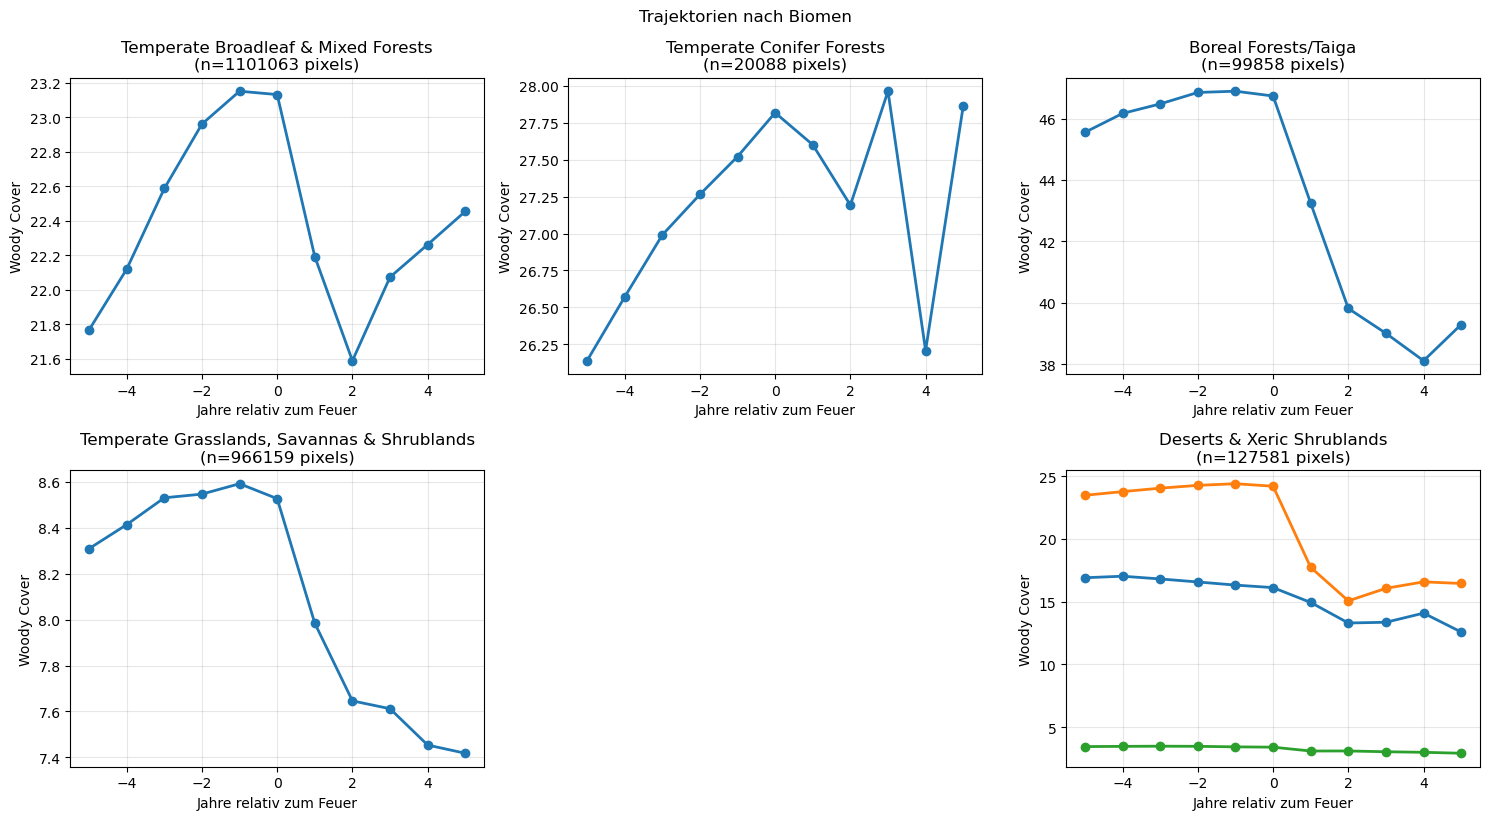


=== STRATIFIZIERUNG NACH ÖKOREGIONEN (TOP 10) ===
Ökoregion 735 (Pontic steppe): 826538 Pixel
Ökoregion 661 (East European forest steppe): 468186 Pixel
Ökoregion 679 (Sarmatic mixed forests): 177799 Pixel
Ökoregion 654 (Central European mixed forests): 174018 Pixel
Ökoregion 815 (Caspian lowland desert): 110775 Pixel
Ökoregion 717 (Scandinavian and Russian taiga): 75941 Pixel
Ökoregion 646 (Balkan mixed forests): 66963 Pixel
Ökoregion 732 (Kazakh steppe): 52373 Pixel
Ökoregion 731 (Kazakh forest steppe): 48229 Pixel
Ökoregion 791 (Eastern Mediterranean conifer-broadleaf forests): 46291 Pixel


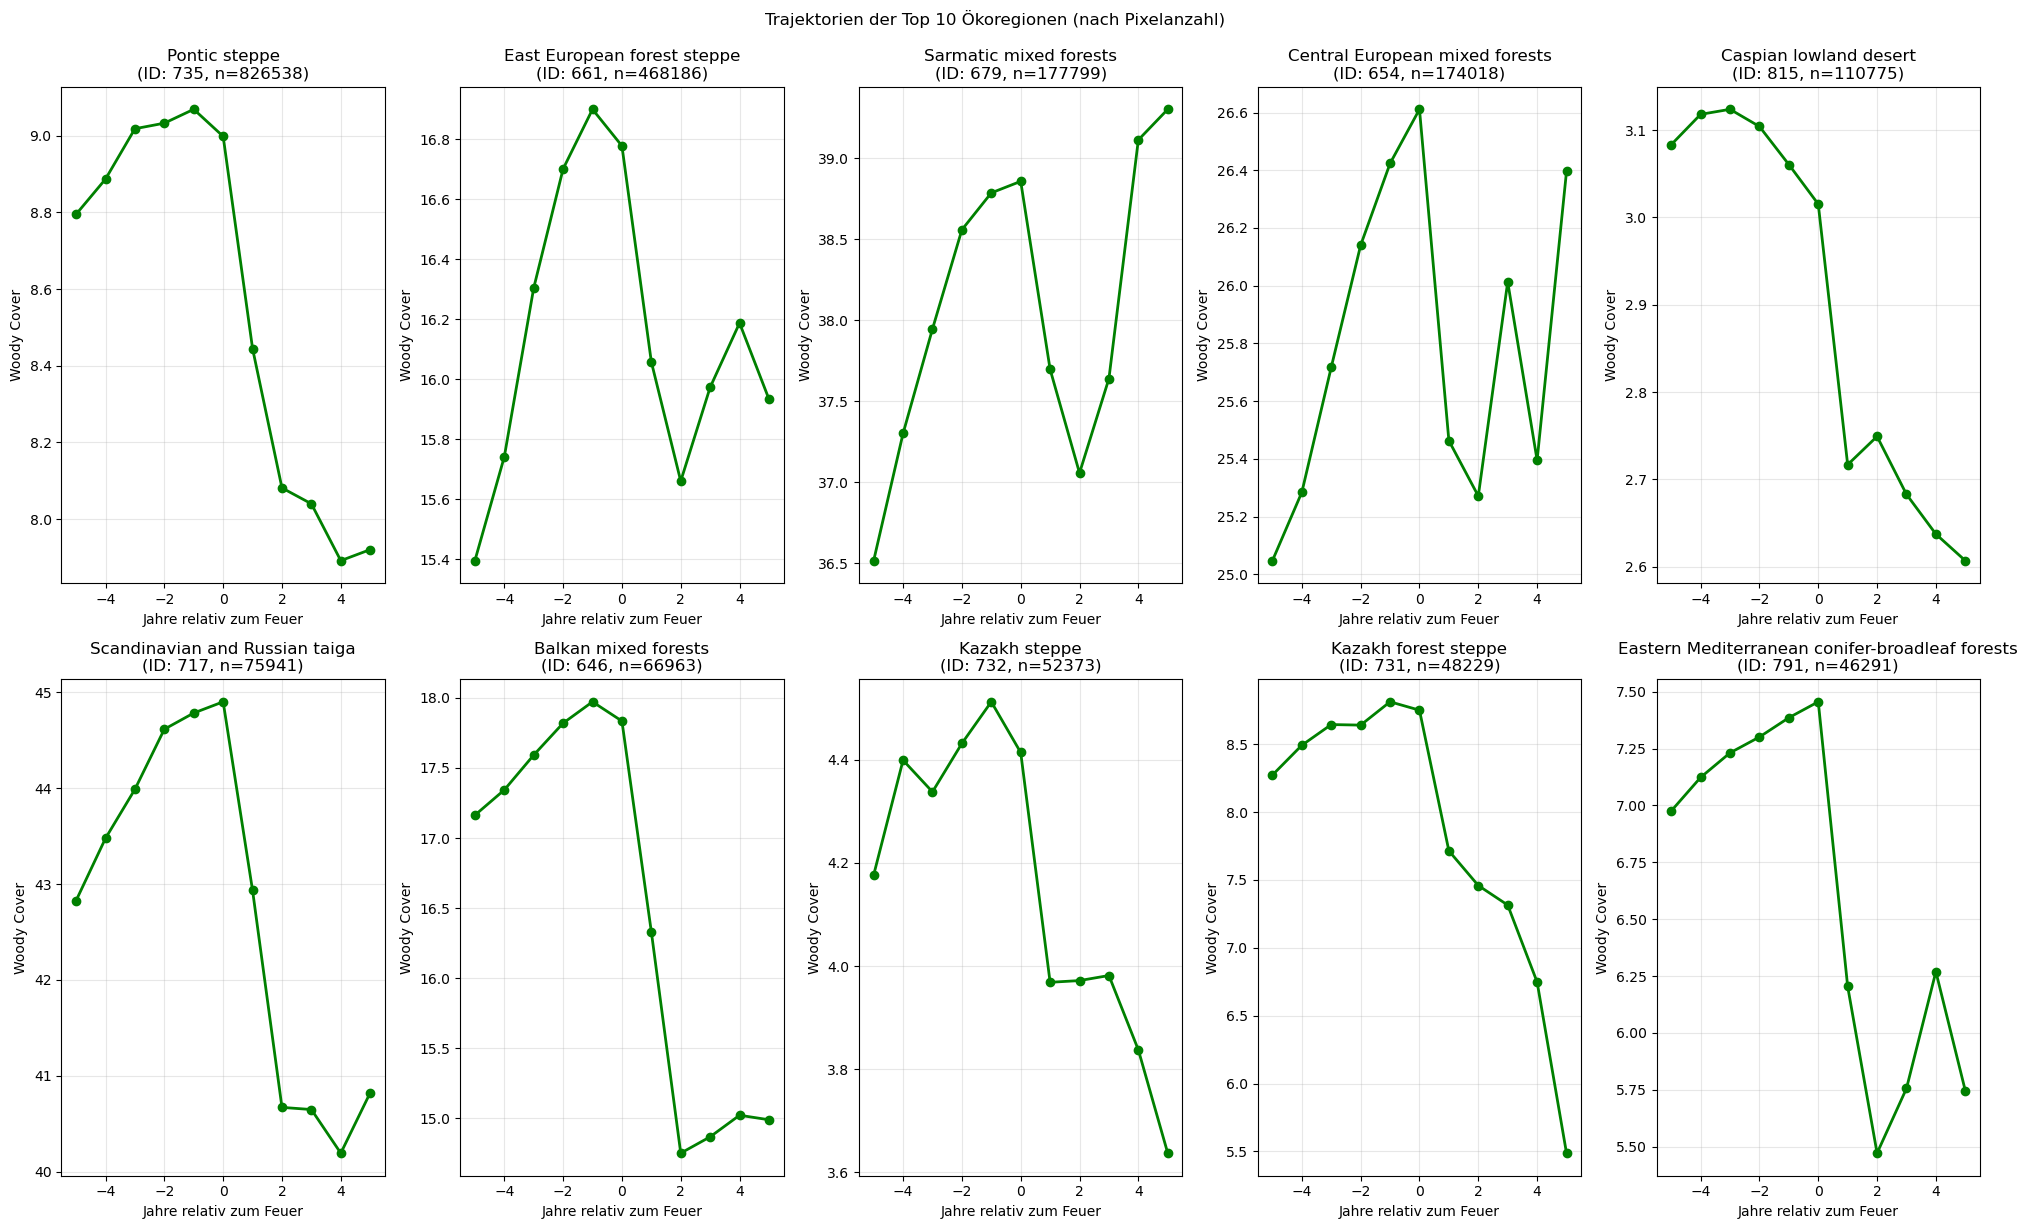

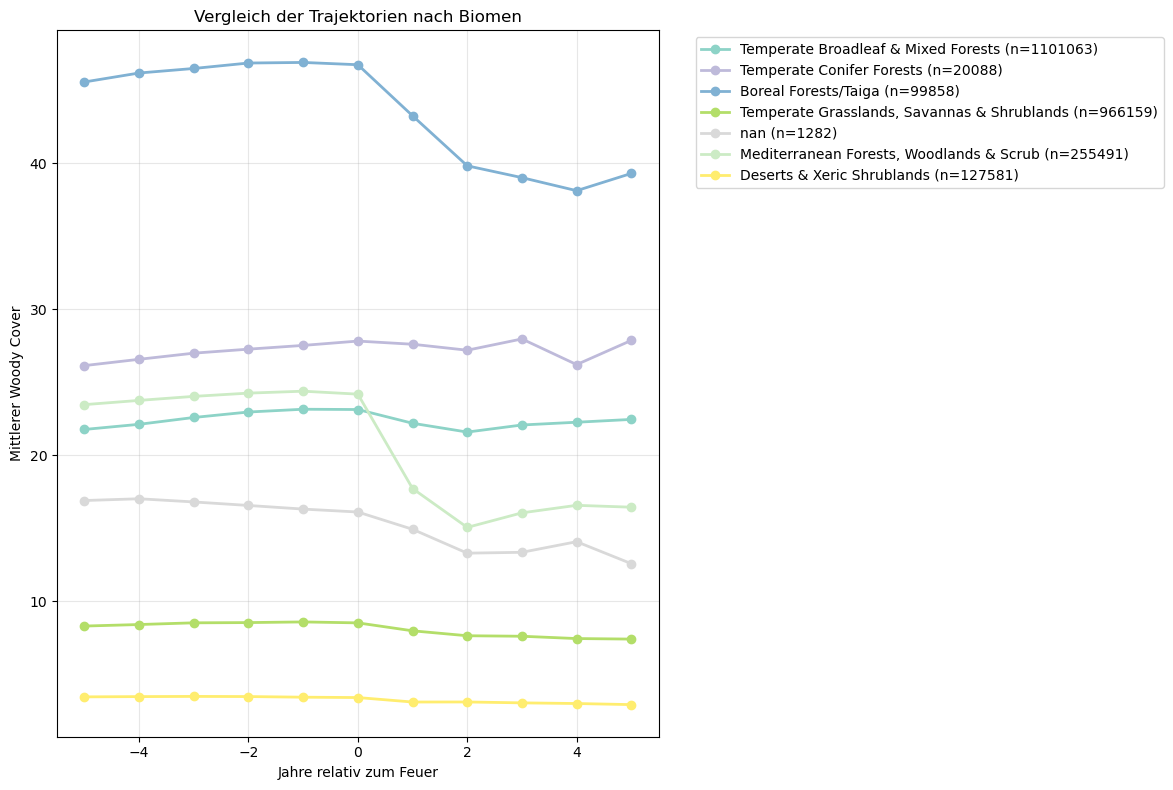


=== ZUSAMMENFASSUNG ===
Analysierte Biome: 7
Analysierte Ökoregionen (Top 10): 10
Gesamtpixel mit 1 Feuer: 2579129


In [13]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

# === DATEN LADEN ===

# Woody & Burned Daten
raster_path = r"\\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs\02_Trajectories_Full\woody_burned_combined.tif"

# Ecoregions Raster (von Ihrem lokalen Workflow)
ecoregions_path = r"\\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs\03_Ecoregions\ecoregions_500m_3035.tif"

# CSV für Namen-Lookup
csv_path = r"\\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs\03_Ecoregions\ecoregions_attributes.csv"

years_woody = list(range(1985, 2026))   # 41 Jahre
years_burned = list(range(2000, 2026))  # 26 Jahre

print("Lade Rasterdaten ...")
with rasterio.open(raster_path) as src:
    woody = src.read(range(1, len(years_woody)+1))
    burned = src.read(range(len(years_woody)+1, src.count+1))
    nodata = src.nodata

with rasterio.open(ecoregions_path) as src:
    eco_id = src.read(1)      # Band 1: ECO_ID
    biome_num = src.read(2)   # Band 2: BIOME_NUM

# Lookup-Tabelle laden
eco_lookup = pd.read_csv(csv_path)

print(f"Woody Shape: {woody.shape}")
print(f"Burned Shape: {burned.shape}")
print(f"Ecoregions Shape: {eco_id.shape}")

# === BASIC MASKS ===

print("Erstelle Basis-Masken ...")
burned_sum = np.sum(burned == 1, axis=0)
single_fire_mask = burned_sum == 1
burned_year_idx = np.argmax(burned == 1, axis=0)

print(f"Pixel mit genau 1 Feuer: {np.sum(single_fire_mask)}")

# === STRATIFIZIERTE TRAJEKTORIEN-FUNKTION ===

def calc_stratified_trajectory(woody, burned_year_idx, single_fire_mask, stratum_mask, 
                              years_woody, years_burned, nodata):
    """Berechnet Trajektorie für eine bestimmte Stratifikation"""
    
    # Kombinierte Maske: Single Fire UND Stratum
    combined_mask = single_fire_mask & stratum_mask
    n_pixels = np.sum(combined_mask)
    
    if n_pixels < 50:  # Mindestanzahl Pixel
        return None, n_pixels
    
    trajectory = []
    for rel_year in range(-5, 6):  # -5 bis +5
        woody_band = burned_year_idx + rel_year + (years_burned[0] - years_woody[0])
        
        # Gültige Pixel für dieses relative Jahr
        valid_mask = (
            (woody_band >= 0) &
            (woody_band < len(years_woody)) &
            combined_mask
        )
        
        if np.sum(valid_mask) == 0:
            trajectory.append(np.nan)
            continue
        
        # Werte extrahieren
        band_vals = np.full_like(burned_sum, np.nan, dtype=float)
        y_idx, x_idx = np.where(valid_mask)
        band_vals[y_idx, x_idx] = woody[woody_band[y_idx, x_idx], y_idx, x_idx]
        band_vals[band_vals == nodata] = np.nan
        
        trajectory.append(np.nanmean(band_vals))
    
    return trajectory, n_pixels

# === STRATIFIZIERUNG NACH BIOMEN ===

print("\n=== STRATIFIZIERUNG NACH BIOMEN ===")

unique_biomes = np.unique(biome_num[biome_num > 0])
biome_trajectories = {}

plt.figure(figsize=(15, 8))

for i, biome_id in enumerate(unique_biomes):
    biome_mask = (biome_num == biome_id)
    trajectory, n_pixels = calc_stratified_trajectory(
        woody, burned_year_idx, single_fire_mask, biome_mask, 
        years_woody, years_burned, nodata
    )
    
    if trajectory is not None:
        biome_name = eco_lookup[eco_lookup['BIOME_NUM'] == biome_id]['BIOME_NAME'].iloc[0] if len(eco_lookup[eco_lookup['BIOME_NUM'] == biome_id]) > 0 else f'Biome {biome_id}'
        biome_trajectories[biome_id] = {
            'trajectory': trajectory,
            'n_pixels': n_pixels,
            'name': biome_name
        }
        
        plt.subplot(2, 3, min(i+1, 6))  # Max 6 Subplots
        plt.plot(range(-5, 6), trajectory, marker='o', linewidth=2)
        plt.title(f'{biome_name}\n(n={n_pixels} pixels)')
        plt.xlabel('Jahre relativ zum Feuer')
        plt.ylabel('Woody Cover')
        plt.grid(True, alpha=0.3)
        
        print(f"Biome {biome_id} ({biome_name}): {n_pixels} Pixel")

plt.tight_layout()
plt.suptitle('Trajektorien nach Biomen', y=1.02)
plt.show()

# === STRATIFIZIERUNG NACH EINZELNEN ÖKOREGIONEN ===

print("\n=== STRATIFIZIERUNG NACH ÖKOREGIONEN (TOP 10) ===")

unique_ecos = np.unique(eco_id[eco_id > 0])
eco_pixel_counts = []

# Pixel pro Ökoregion zählen
for eco in unique_ecos:
    eco_mask = (eco_id == eco)
    combined_mask = single_fire_mask & eco_mask
    n_pixels = np.sum(combined_mask)
    if n_pixels >= 100:  # Mindestens 100 Pixel
        eco_pixel_counts.append((eco, n_pixels))

# Nach Pixelanzahl sortieren und Top 10 nehmen
eco_pixel_counts.sort(key=lambda x: x[1], reverse=True)
top_ecoregions = eco_pixel_counts[:10]

plt.figure(figsize=(20, 12))

for i, (eco_id_val, pixel_count) in enumerate(top_ecoregions):
    eco_mask = (eco_id == eco_id_val)
    trajectory, n_pixels = calc_stratified_trajectory(
        woody, burned_year_idx, single_fire_mask, eco_mask, 
        years_woody, years_burned, nodata
    )
    
    if trajectory is not None:
        eco_name = eco_lookup[eco_lookup['ECO_ID'] == eco_id_val]['ECO_NAME'].iloc[0] if len(eco_lookup[eco_lookup['ECO_ID'] == eco_id_val]) > 0 else f'Ecoregion {eco_id_val}'
        
        plt.subplot(2, 5, i+1)
        plt.plot(range(-5, 6), trajectory, marker='o', linewidth=2, color='green')
        plt.title(f'{eco_name}\n(ID: {eco_id_val}, n={n_pixels})')
        plt.xlabel('Jahre relativ zum Feuer')
        plt.ylabel('Woody Cover')
        plt.grid(True, alpha=0.3)
        
        print(f"Ökoregion {eco_id_val} ({eco_name}): {n_pixels} Pixel")

plt.tight_layout()
plt.suptitle('Trajektorien der Top 10 Ökoregionen (nach Pixelanzahl)', y=1.02)
plt.show()

# === VERGLEICHSPLOT: ALLE BIOME IN EINEM PLOT ===

plt.figure(figsize=(12, 8))
colors = plt.cm.Set3(np.linspace(0, 1, len(biome_trajectories)))

for i, (biome_id, data) in enumerate(biome_trajectories.items()):
    plt.plot(range(-5, 6), data['trajectory'], 
             marker='o', linewidth=2, label=f"{data['name']} (n={data['n_pixels']})",
             color=colors[i])

plt.xlabel('Jahre relativ zum Feuer')
plt.ylabel('Mittlerer Woody Cover')
plt.title('Vergleich der Trajektorien nach Biomen')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== ZUSAMMENFASSUNG ===")
print(f"Analysierte Biome: {len(biome_trajectories)}")
print(f"Analysierte Ökoregionen (Top 10): {len(top_ecoregions)}")
print(f"Gesamtpixel mit 1 Feuer: {np.sum(single_fire_mask)}")


=== STRATIFIZIERUNG NACH BIOMEN (KORRIGIERT) ===
Biome 4 (Temperate Broadleaf & Mixed Forests): 1101063 Pixel
  Enthält 25 Ecoregions: [688 649 644 676 678 646 660 675 648 651 652 662 665 650 658 674 686 664
 654 663 647 679 672 687 661]
Biome 5 (Temperate Conifer Forests): 20088 Pixel
  Enthält 7 Ecoregions: [695 689 701 703 692 708 691]
Biome 6 (Boreal Forests/Taiga): 99858 Pixel
  Enthält 4 Ecoregions: [711 719 720 717]
Biome 8 (Temperate Grasslands, Savannas & Shrublands): 966159 Pixel
  Enthält 8 Ecoregions: [739 725 727 735 732 733 731 729]
Biome 11 (nan): 1282 Pixel
  Enthält 7 Ecoregions: [  0 780 417 776 784 774 778]
Biome 12 (Mediterranean Forests, Woodlands & Scrub): 255491 Pixel
  Enthält 21 Ecoregions: [796 797 798 789 802 785 801 806 788 791 790 804 786 799 795 794 803 805
 792 793 800]
Biome 13 (Deserts & Xeric Shrublands): 127581 Pixel
  Enthält 13 Ecoregions: [837 809 819 810 833 831 830 841 820 812 815 817 828]


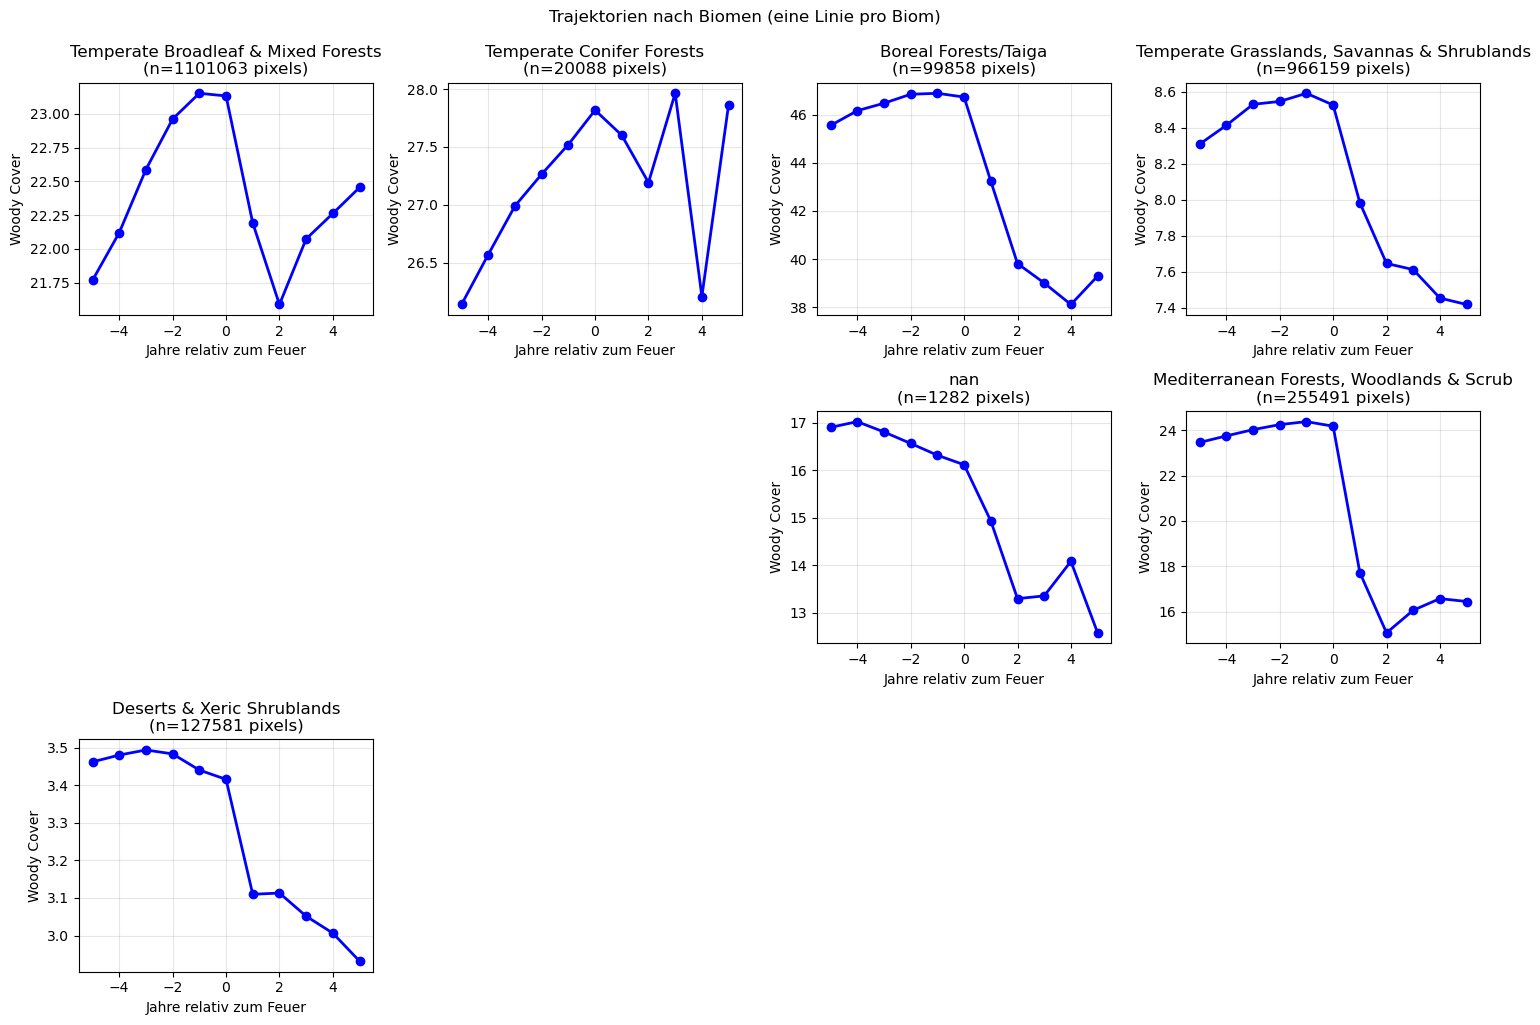


=== DETAILANALYSE: ECOREGIONS PRO BIOM ===
  Ecoregion 830 (Mesopotamian shrub desert): 281 Pixel
  Ecoregion 820 (Central Persian desert basins): 62 Pixel


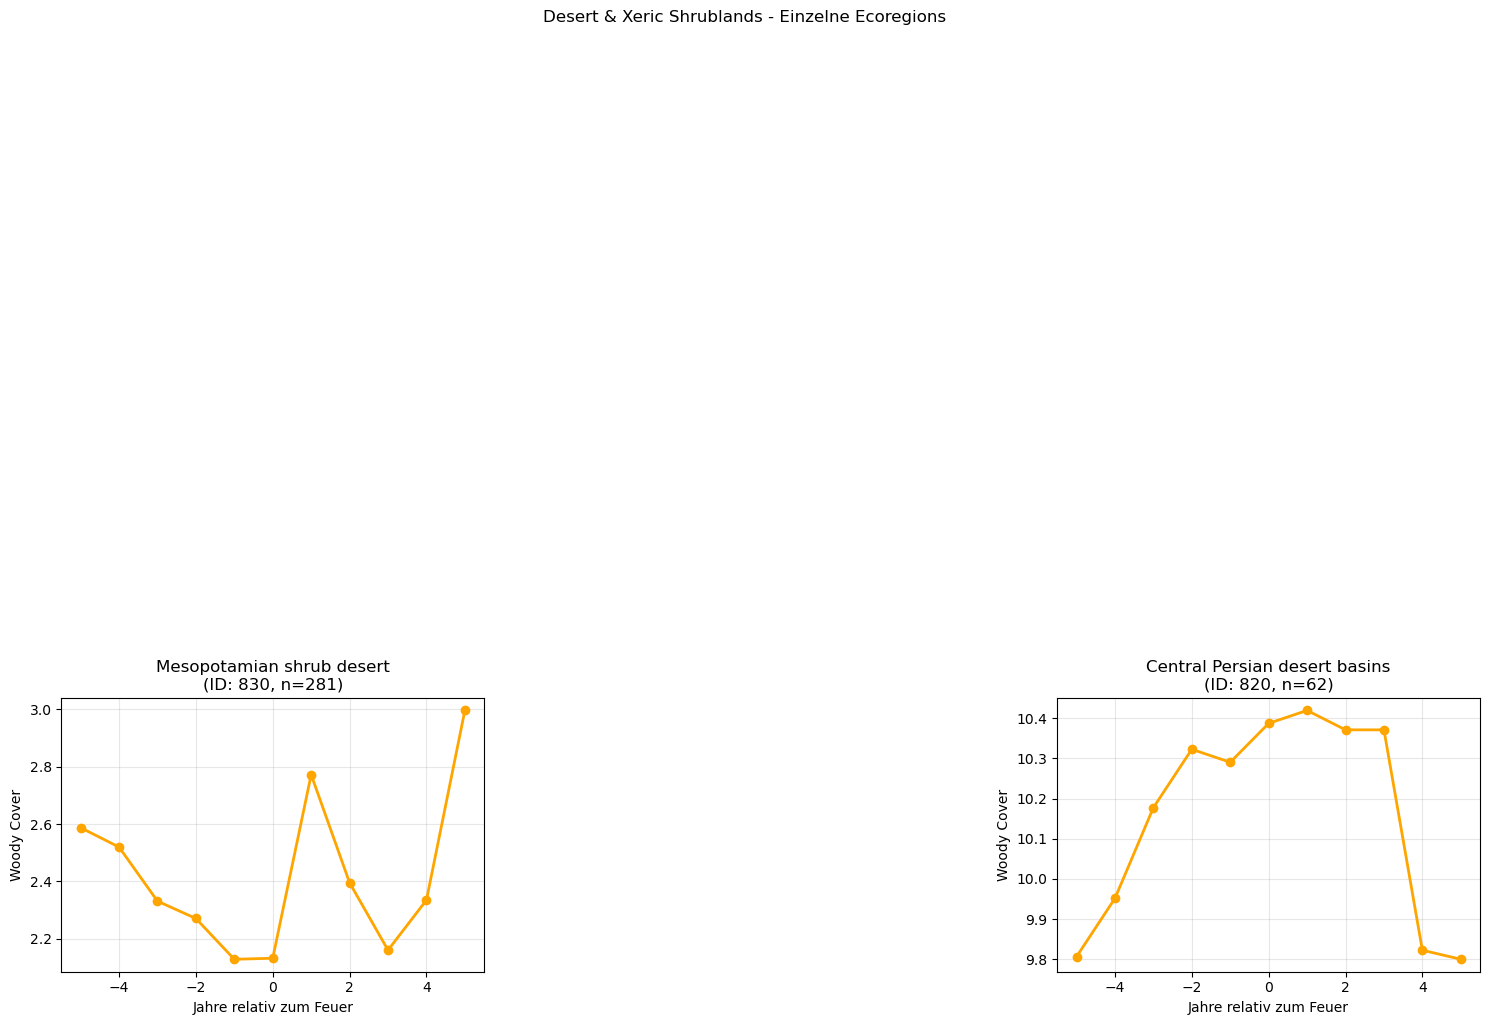

In [14]:
# === KORRIGIERTE STRATIFIZIERUNG NACH BIOMEN ===

print("\n=== STRATIFIZIERUNG NACH BIOMEN (KORRIGIERT) ===")

unique_biomes = np.unique(biome_num[biome_num > 0])
biome_trajectories = {}

plt.figure(figsize=(15, 10))

for i, biome_id in enumerate(unique_biomes):
    # ALLE Pixel dieses Bioms kombinieren (unabhängig von ECO_ID)
    biome_mask = (biome_num == biome_id)
    
    # Einzelne Trajektorie für das gesamte Biom berechnen
    trajectory, n_pixels = calc_stratified_trajectory(
        woody, burned_year_idx, single_fire_mask, biome_mask, 
        years_woody, years_burned, nodata
    )
    
    if trajectory is not None:
        # Biome-Namen aus CSV holen
        biome_name = eco_lookup[eco_lookup['BIOME_NUM'] == biome_id]['BIOME_NAME'].iloc[0] \
                     if len(eco_lookup[eco_lookup['BIOME_NUM'] == biome_id]) > 0 else f'Biome {biome_id}'
        
        biome_trajectories[biome_id] = {
            'trajectory': trajectory,
            'n_pixels': n_pixels,
            'name': biome_name
        }
        
        plt.subplot(3, 4, i+1)  # Angepasste Subplot-Anzahl
        plt.plot(range(-5, 6), trajectory, marker='o', linewidth=2, color='blue')
        plt.title(f'{biome_name}\n(n={n_pixels} pixels)')
        plt.xlabel('Jahre relativ zum Feuer')
        plt.ylabel('Woody Cover')
        plt.grid(True, alpha=0.3)
        
        # Ecoregions in diesem Biom auflisten
        eco_ids_in_biom = eco_lookup[eco_lookup['BIOME_NUM'] == biome_id]['ECO_ID'].unique()
        print(f"Biome {biome_id} ({biome_name}): {n_pixels} Pixel")
        print(f"  Enthält {len(eco_ids_in_biom)} Ecoregions: {eco_ids_in_biom}")

plt.tight_layout()
plt.suptitle('Trajektorien nach Biomen (eine Linie pro Biom)', y=1.02)
plt.show()

# === ALTERNATIVE: ECOREGIONS INNERHALB VON BIOMEN ANZEIGEN ===

print("\n=== DETAILANALYSE: ECOREGIONS PRO BIOM ===")

# Fokus auf Deserts & Xeric Shrublands (BIOME_NUM = 13)
desert_biome_id = 13
desert_ecoregions = eco_lookup[eco_lookup['BIOME_NUM'] == desert_biome_id]

plt.figure(figsize=(15, 10))

for i, (idx, row) in enumerate(desert_ecoregions.iterrows()):
    if i >= 9:  # Nur erste 9 Ecoregions zeigen
        break
        
    eco_id_val = row['ECO_ID']
    eco_name = row['ECO_NAME']
    
    # Einzelne Ecoregion-Maske
    eco_mask = (eco_id == eco_id_val)
    
    trajectory, n_pixels = calc_stratified_trajectory(
        woody, burned_year_idx, single_fire_mask, eco_mask, 
        years_woody, years_burned, nodata
    )
    
    if trajectory is not None and n_pixels >= 10:  # Mindestens 10 Pixel
        plt.subplot(3, 3, i+1)
        plt.plot(range(-5, 6), trajectory, marker='o', linewidth=2, color='orange')
        plt.title(f'{eco_name}\n(ID: {eco_id_val}, n={n_pixels})')
        plt.xlabel('Jahre relativ zum Feuer')
        plt.ylabel('Woody Cover')
        plt.grid(True, alpha=0.3)
        
        print(f"  Ecoregion {eco_id_val} ({eco_name}): {n_pixels} Pixel")

plt.tight_layout()
plt.suptitle('Desert & Xeric Shrublands - Einzelne Ecoregions', y=1.02)
plt.show()

# Stratifizierung nach Anzahl Brandereignisse

Diese Erweiterung ermöglicht es Ihnen:

- Verschiedene Brandkategorien zu analysieren (1x, 2x, 3x, ≥2x, ≥4x Brände)
- Trajektorien zu vergleichen zwischen Einzel- und Mehrfachbränden
- Statistiken über die Häufigkeitsverteilung zu erhalten
- Die Recovery-Unterschiede zwischen verschiedenen Brandintensitäten zu verstehen


Die Implementierung nutzt Ihre bestehende Struktur und erweitert sie um die Mehrfachbrand-Analyse. Sie können diese Ansätze auch mit Ihren Biom-Stratifizierungen kombinieren, um zu sehen, wie sich Mehrfachbrände in verschiedenen Ökosystemen unterschiedlich auswirken.


In [ ]:
# === STRATIFIZIERUNG NACH ANZAHL BRANDEREIGNISSE ===

print("\n=== STRATIFIZIERUNG NACH ANZAHL BRANDEREIGNISSE ===")

# Verschiedene Feuer-Kategorien erstellen
fire_counts = np.sum(burned == 1, axis=0)  # Gesamtanzahl Brände pro Pixel

# Masken für verschiedene Brandkategorien
single_fire_mask = (fire_counts == 1)
double_fire_mask = (fire_counts == 2)  
triple_fire_mask = (fire_counts == 3)
multi_fire_mask = (fire_counts >= 2)  # 2 oder mehr Brände
many_fires_mask = (fire_counts >= 4)   # 4 oder mehr Brände

fire_categories = {
    'Einzelbrand (1x)': single_fire_mask,
    'Zweifachbrand (2x)': double_fire_mask,
    'Dreifachbrand (3x)': triple_fire_mask,
    'Mehrfachbrand (≥2x)': multi_fire_mask,
    'Viele Brände (≥4x)': many_fires_mask
}

plt.figure(figsize=(15, 10))

for i, (category_name, fire_mask) in enumerate(fire_categories.items()):
    n_pixels = np.sum(fire_mask)
    print(f"{category_name}: {n_pixels} Pixel")
    
    if n_pixels < 50:  # Mindestanzahl für sinnvolle Statistik
        print(f"  Zu wenige Pixel für {category_name}")
        continue
    
    # Für Mehrfachbrände: nehmen wir das erste Brandereignis als Referenz
    if np.sum(fire_mask) > 0:
        # Trajectory berechnen (angepasste Funktion nötig)
        trajectory = calc_multi_fire_trajectory(
            woody, burned, fire_mask, years_woody, years_burned, nodata
        )
        
        if trajectory is not None:
            plt.subplot(2, 3, i+1)
            plt.plot(range(-5, 6), trajectory, marker='o', linewidth=2)
            plt.title(f'{category_name}\n(n={n_pixels} pixels)')
            plt.xlabel('Jahre relativ zum (ersten) Feuer')
            plt.ylabel('Woody Cover')
            plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Trajektorien nach Anzahl Brandereignisse', y=1.02)
plt.show()

Erweiterte Trajektorien-Funktion für Mehrfachbrände


In [ ]:
def calc_multi_fire_trajectory(woody, burned, fire_mask, years_woody, years_burned, nodata):
    """
    Berechnet Trajektorie für Pixel mit mehreren Brandereignissen
    Verwendet das ERSTE Brandereignis als Referenzpunkt
    """
    if np.sum(fire_mask) < 50:
        return None
    
    # Erstes Brandereignis pro Pixel finden
    first_burn_year_idx = np.full_like(fire_mask, -1, dtype=int)
    
    for year_idx in range(burned.shape[0]):  # Über alle Brandjahre
        year_burned = (burned[year_idx] == 1) & fire_mask
        # Setze Jahr nur für Pixel, die noch kein erstes Brandjahr haben
        first_burn_year_idx[(first_burn_year_idx == -1) & year_burned] = year_idx
    
    # Nur Pixel mit gültigem erstem Brandjahr
    valid_pixels = (first_burn_year_idx >= 0) & fire_mask
    
    if np.sum(valid_pixels) < 50:
        return None
    
    trajectory = []
    for rel_year in range(-5, 6):  # -5 bis +5 Jahre relativ zum ersten Brand
        woody_band = first_burn_year_idx + rel_year + (years_burned[0] - years_woody[0])
        
        # Gültige Pixel für dieses relative Jahr
        final_mask = (
            (woody_band >= 0) &
            (woody_band < len(years_woody)) &
            valid_pixels
        )
        
        if np.sum(final_mask) == 0:
            trajectory.append(np.nan)
            continue
        
        # Werte extrahieren
        band_vals = np.full(fire_mask.shape, np.nan, dtype=float)
        y_idx, x_idx = np.where(final_mask)
        band_vals[y_idx, x_idx] = woody[woody_band[y_idx, x_idx], y_idx, x_idx]
        band_vals[band_vals == nodata] = np.nan
        
        trajectory.append(np.nanmean(band_vals))
    
    return trajectory

Vergleichsplot: 1 vs. Mehrere Brände


In [ ]:
# === DIREKTER VERGLEICH: EINZEL- VS. MEHRFACHBRÄNDE ===

print("\n=== VERGLEICH: EINZEL- VS. MEHRFACHBRÄNDE ===")

plt.figure(figsize=(15, 5))

# Einzelbrände
single_trajectory = calc_multi_fire_trajectory(
    woody, burned, single_fire_mask, years_woody, years_burned, nodata
)

# Mehrfachbrände (≥2)
multi_trajectory = calc_multi_fire_trajectory(
    woody, burned, multi_fire_mask, years_woody, years_burned, nodata
)

# Subplot 1: Einzelbrände
plt.subplot(1, 3, 1)
if single_trajectory is not None:
    plt.plot(range(-5, 6), single_trajectory, marker='o', linewidth=2, color='blue')
plt.title(f'Einzelbrände\n(n={np.sum(single_fire_mask)} pixels)')
plt.xlabel('Jahre relativ zum Feuer')
plt.ylabel('Woody Cover')
plt.grid(True, alpha=0.3)

# Subplot 2: Mehrfachbrände  
plt.subplot(1, 3, 2)
if multi_trajectory is not None:
    plt.plot(range(-5, 6), multi_trajectory, marker='o', linewidth=2, color='red')
plt.title(f'Mehrfachbrände (≥2)\n(n={np.sum(multi_fire_mask)} pixels)')
plt.xlabel('Jahre relativ zum ersten Feuer')
plt.ylabel('Woody Cover')
plt.grid(True, alpha=0.3)

# Subplot 3: Direkter Vergleich
plt.subplot(1, 3, 3)
if single_trajectory is not None:
    plt.plot(range(-5, 6), single_trajectory, marker='o', linewidth=2, 
             color='blue', label=f'Einzelbrände (n={np.sum(single_fire_mask)})')
if multi_trajectory is not None:
    plt.plot(range(-5, 6), multi_trajectory, marker='s', linewidth=2, 
             color='red', label=f'Mehrfachbrände (n={np.sum(multi_fire_mask)})')
plt.title('Direkter Vergleich')
plt.xlabel('Jahre relativ zum (ersten) Feuer')
plt.ylabel('Woody Cover')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Statistiken zu Brandhäufigkeiten


In [ ]:
# === STATISTIKEN ZU BRANDHÄUFIGKEITEN ===

print("\n=== BRANDHÄUFIGKEITS-STATISTIKEN ===")

fire_count_stats = []
for n_fires in range(1, int(np.max(fire_counts)) + 1):
    mask = (fire_counts == n_fires)
    n_pixels = np.sum(mask)
    percentage = (n_pixels / np.sum(fire_counts > 0)) * 100
    
    fire_count_stats.append({
        'Anzahl_Brände': n_fires,
        'Pixel': n_pixels,
        'Prozent': round(percentage, 2)
    })
    
    print(f"{n_fires} Brand(e): {n_pixels:,} Pixel ({percentage:.1f}%)")

# Als DataFrame für weitere Analyse
fire_stats_df = pd.DataFrame(fire_count_stats)
print(f"\nGesamtpixel mit mindestens 1 Brand: {np.sum(fire_counts > 0):,}")

# Histogramm der Brandhäufigkeiten
plt.figure(figsize=(10, 6))
plt.hist(fire_counts[fire_counts > 0], bins=range(1, int(np.max(fire_counts))+2), 
         alpha=0.7, edgecolor='black')
plt.xlabel('Anzahl Brandereignisse pro Pixel')
plt.ylabel('Anzahl Pixel')
plt.title('Verteilung der Brandhäufigkeiten')
plt.yscale('log')  # Logarithmische Skala für bessere Sichtbarkeit
plt.grid(True, alpha=0.3)
plt.show()